# DS-01

Clustering fundamentals: $k$-means, DBSCAN, OPTICS, and practical
applications.

**Web page:** <a href="https://apagyidavid.web.elte.hu/2025-2026-2/ds"
target="_blank">apagyidavid.web.elte.hu/2025-2026-2/ds</a>

<a target="_blank" href="https://colab.research.google.com/github/dapagyi/ds-web/blob/notebooks/ds-01.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering With $k$-Means, DBSCAN, and OPTICS

This notebook covers:

- centroid-based clustering ($k$-means),
- density-based clustering (DBSCAN, OPTICS),
- model selection and diagnostics,
- practical examples (color quantization/segmentation, hierarchical
  demo, seismic activity clustering).

In [1]:
import warnings

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.animation import FuncAnimation
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import (
    AgglomerativeClustering,
    DBSCAN,
    KMeans,
    MiniBatchKMeans,
    OPTICS,
    SpectralClustering,
)
from sklearn.datasets import (
    load_sample_image,
    make_blobs,
    make_circles,
    make_moons,
)
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.metrics.pairwise import pairwise_distances_argmin
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MaxAbsScaler

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(seed=333)
warnings.simplefilter("ignore")

## A Simple $k$-Means Example

In [2]:
X_blobs, _ = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.60,
    random_state=0,
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_blobs[:, 0], X_blobs[:, 1], s=40, color="tab:blue", alpha=0.82)
ax.set_title("Unlabeled dataset")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.show()

In [3]:
kmeans = KMeans(n_clusters=4, n_init=10, random_state=0)
labels_blobs = kmeans.fit_predict(X_blobs)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_blobs, s=40, cmap="viridis", alpha=0.85)
ax.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c="black",
    s=220,
    marker="X",
)
ax.set_title("$k$-means result")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.show()

## Expectation-Maximization View of $k$-Means

Let $X = \{x_i\}_{i=1}^n$, with $x_i \in \mathbb{R}^d$, and let $k$ be
the number of clusters.

Define binary assignment variables:

$$r_{ij} =
\begin{cases}
1, & \text{if point } i \text{ is assigned to cluster } j,\\
0, & \text{otherwise.}
\end{cases}$$

The objective minimized by $k$-means is

$$J(r, \mu) = \sum_{i=1}^n \sum_{j=1}^k r_{ij}\,\|x_i - \mu_j\|_2^2,$$

subject to $\sum_{j=1}^k r_{ij} = 1$ for each $i$.

At each iteration:

- Assignment step (E-like step):
  $$r_{ij} \leftarrow 1\{j = \arg\min_{\ell} \|x_i - \mu_{\ell}\|_2^2\}$$
- Update step (M-like step):
  $$\mu_j \leftarrow \frac{\sum_i r_{ij} x_i}{\sum_i r_{ij}}$$

Each full iteration does not increase $J$.

In [4]:
def kmeans_em_history(X, n_clusters=4, random_state=0, max_iter=12):
    rng_local = np.random.default_rng(seed=random_state)
    idx = rng_local.choice(X.shape[0], size=n_clusters, replace=False)
    centers = X[idx].copy()

    history = []
    for _ in range(max_iter):
        labels = pairwise_distances_argmin(X, centers)
        history.append((centers.copy(), labels.copy()))
        new_centers = np.array([X[labels == j].mean(axis=0) for j in range(n_clusters)])

        if np.allclose(new_centers, centers):
            centers = new_centers
            labels = pairwise_distances_argmin(X, centers)
            history.append((centers.copy(), labels.copy()))
            break
        centers = new_centers

    return history

In [5]:
history = kmeans_em_history(X_blobs, n_clusters=4, random_state=1, max_iter=8)
frames_to_show = np.unique(np.linspace(0, len(history) - 1, 4, dtype=int))

fig, axes = plt.subplots(1, 4, figsize=(12, 3.2), constrained_layout=True)
for ax, step in zip(axes, frames_to_show):
    centers_step, labels_step = history[step]
    ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_step, cmap="viridis", s=20, alpha=0.85)
    ax.scatter(centers_step[:, 0], centers_step[:, 1], c="black", marker="X", s=150)
    ax.set_title(f"Step {step}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.show()

In [6]:
# Notebook-only: animated EM progression

fig, ax = plt.subplots(figsize=(8, 6))

def update(frame):
    ax.clear()
    centers_step, labels_step = history[frame]
    ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_step, cmap="viridis", s=25, alpha=0.85)
    ax.scatter(centers_step[:, 0], centers_step[:, 1], c="black", marker="X", s=200)
    ax.set_title(f"$k$-means EM steps - frame {frame}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    return []

anim = FuncAnimation(fig, update, frames=len(history), interval=700, repeat=True)
plt.close(fig)
anim

## A Minimal From-Scratch Implementation

In [7]:
def find_clusters(X, n_clusters, random_state=2, max_iter=300):
    rng_local = np.random.default_rng(seed=random_state)
    idx = rng_local.choice(X.shape[0], size=n_clusters, replace=False)
    centers = X[idx].copy()

    for _ in range(max_iter):
        labels = pairwise_distances_argmin(X, centers)
        new_centers = np.array([X[labels == i].mean(axis=0) for i in range(n_clusters)])
        if np.allclose(new_centers, centers):
            break
        centers = new_centers

    return centers, labels

In [8]:
centers_scratch, labels_scratch = find_clusters(X_blobs, n_clusters=4, random_state=2)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_scratch, s=40, cmap="viridis", alpha=0.85)
ax.scatter(centers_scratch[:, 0], centers_scratch[:, 1], c="black", s=220, marker="X")
ax.set_title("From-scratch implementation")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.show()

## Caveats of $k$-Means

### Sensitivity to Initialization

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

for ax, seed in zip(axes, [0, 7]):
    centers_seed, labels_seed = find_clusters(X_blobs, n_clusters=4, random_state=seed)
    ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_seed, s=30, cmap="viridis", alpha=0.85)
    ax.scatter(centers_seed[:, 0], centers_seed[:, 1], c="black", s=170, marker="X")
    ax.set_title(f"random_state={seed}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.show()

### Number of Clusters Must Be Chosen

In [10]:
labels_k6 = KMeans(n_clusters=6, n_init=10, random_state=0).fit_predict(X_blobs)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_k6, s=40, cmap="viridis", alpha=0.85)
ax.set_title("$k$-means with $k=6$")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.show()

Silhouette analysis helps compare candidate values of $k$.

In [11]:
def silhouette_analysis(X, cluster_values, random_state=0):
    for n_clusters in cluster_values:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

        model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
        labels = model.fit_predict(X)

        sil_avg = silhouette_score(X, labels)
        sil_values = silhouette_samples(X, labels)

        y_lower = 10
        for i in range(n_clusters):
            vals_i = sil_values[labels == i]
            vals_i.sort()
            size_i = vals_i.shape[0]
            y_upper = y_lower + size_i

            color = cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                vals_i,
                facecolor=color,
                edgecolor=color,
                alpha=0.75,
            )
            ax1.text(-0.06, y_lower + 0.5 * size_i, str(i))
            y_lower = y_upper + 10

        ax1.axvline(x=sil_avg, color="red", linestyle="--", linewidth=1.5)
        ax1.set_title(f"Silhouette (k={n_clusters}, avg={sil_avg:.3f})")
        ax1.set_xlabel("Silhouette coefficient")
        ax1.set_ylabel("Cluster index")
        ax1.set_xlim([-0.1, 1.0])
        ax1.set_yticks([])

        scatter_colors = cm.nipy_spectral(labels.astype(float) / n_clusters)
        ax2.scatter(X[:, 0], X[:, 1], marker="o", s=25, c=scatter_colors, alpha=0.85, edgecolors="none")
        ax2.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], marker="X", c="black", s=170)
        ax2.set_title("Clustered data")
        ax2.set_xlabel("Feature 1")
        ax2.set_ylabel("Feature 2")

        plt.show()

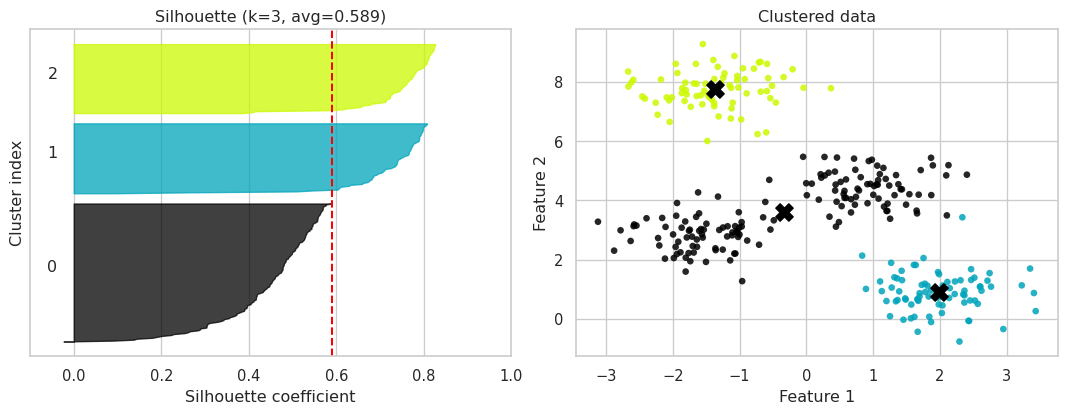

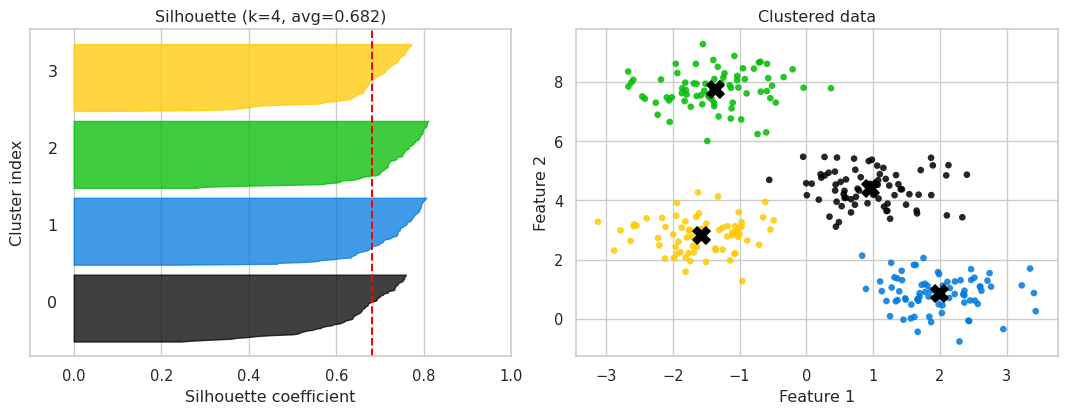

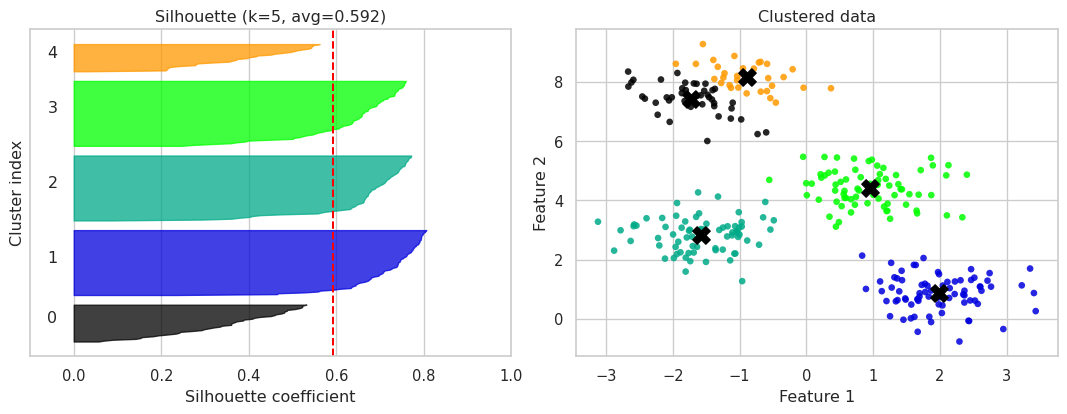

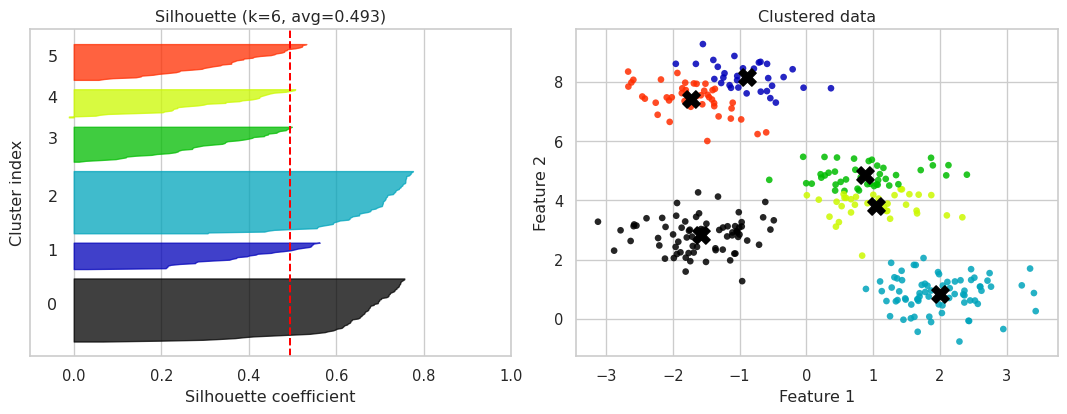

In [12]:
silhouette_analysis(X_blobs, cluster_values=[3, 4, 5, 6], random_state=0)

## Nonlinear Shapes: Where $k$-Means Struggles

In [13]:
X_moons, _ = make_moons(n_samples=240, noise=0.06, random_state=0)
labels_moons_kmeans = KMeans(n_clusters=2, random_state=0, n_init=10).fit_predict(X_moons)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_moons_kmeans, s=40, cmap="viridis", alpha=0.85)
ax.set_title("$k$-means on moons")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.show()

In [14]:
spectral = SpectralClustering(
    n_clusters=2,
    affinity="nearest_neighbors",
    assign_labels="kmeans",
    random_state=0,
)
labels_moons_spectral = spectral.fit_predict(X_moons)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_moons_spectral, s=40, cmap="viridis", alpha=0.85)
ax.set_title("Spectral clustering on moons")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.show()

## Color Quantization and Segmentation

Clustering pixels in RGB space is a basic **color quantization** method.
The same labels can also be used for coarse **segmentation**.

In [15]:
def quantize_image(img, n_colors, random_state=0):
    pixels = (img / 255.0).reshape(-1, 3)
    model = MiniBatchKMeans(n_clusters=n_colors, random_state=random_state, n_init=5)
    labels = model.fit_predict(pixels)
    quantized = model.cluster_centers_[labels].reshape(img.shape)
    label_map = labels.reshape(img.shape[:2])
    return quantized, label_map

In [16]:
china = load_sample_image("china.jpg")
flower = load_sample_image("flower.jpg")

palette_sizes = [4, 8, 16, 32]

fig, axes = plt.subplots(2, len(palette_sizes) + 1, figsize=(14, 6), constrained_layout=True)

axes[0, 0].imshow(china)
axes[0, 0].set_title("china: original")
axes[0, 0].set_axis_off()

axes[1, 0].imshow(flower)
axes[1, 0].set_title("flower: original")
axes[1, 0].set_axis_off()

for j, n_colors in enumerate(palette_sizes, start=1):
    q_china, _ = quantize_image(china, n_colors=n_colors, random_state=0)
    q_flower, _ = quantize_image(flower, n_colors=n_colors, random_state=0)

    axes[0, j].imshow(q_china)
    axes[0, j].set_title(f"{n_colors} colors")
    axes[0, j].set_axis_off()

    axes[1, j].imshow(q_flower)
    axes[1, j].set_title(f"{n_colors} colors")
    axes[1, j].set_axis_off()

plt.show()

In [17]:
q8, labels8 = quantize_image(china, n_colors=8, random_state=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
axes[0].imshow(q8)
axes[0].set_title("Quantized image (8 colors)")
axes[0].set_axis_off()

im = axes[1].imshow(labels8, cmap="tab20")
axes[1].set_title("Segment labels")
axes[1].set_axis_off()
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.show()

## Density-Based Clustering: DBSCAN and OPTICS

In [18]:
blobs_x, _ = make_blobs(n_samples=400, centers=2, cluster_std=1.3, random_state=333)
circle_x, _ = make_circles(n_samples=300, noise=0.09, factor=0.3, random_state=333)
moon_x, _ = make_moons(n_samples=300, noise=0.07, random_state=333)

X_mix = np.concatenate([blobs_x, 3 * moon_x + 9, 3 * circle_x - 13], axis=0)
X_mix[:, 1] = X_mix[:, 1] / 7
rng.shuffle(X_mix)


def visualize_clusters(X, labels=None, cluster_centers=None, title=""):
    fig, ax = plt.subplots(figsize=(8, 6))
    if labels is None:
        ax.scatter(X[:, 0], X[:, 1], s=12, color="tab:blue", alpha=0.85)
    else:
        ax.scatter(X[:, 0], X[:, 1], s=12, c=labels, cmap="viridis", alpha=0.85)

    if cluster_centers is not None:
        ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1], c="black", s=220, marker="X", alpha=0.9)

    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    plt.show()

In [19]:
visualize_clusters(X_mix, title="Composite dataset")

### Revisiting $k$-Means

In [20]:
scaler = MaxAbsScaler()
X_mix_scaled = scaler.fit_transform(X_mix)

kmeans_mix = KMeans(n_clusters=6, n_init=10, random_state=333)
labels_mix_kmeans = kmeans_mix.fit_predict(X_mix_scaled)
centers_original_scale = scaler.inverse_transform(kmeans_mix.cluster_centers_)

visualize_clusters(
    X_mix,
    labels_mix_kmeans,
    centers_original_scale,
    title="$k$-means on normalized data ($k=6$)",
)

### DBSCAN and OPTICS: Static Demo

In [21]:
labels_dbscan = DBSCAN(eps=0.04, min_samples=8).fit_predict(X_mix_scaled)
labels_optics = OPTICS(min_samples=8, xi=0.05, min_cluster_size=0.03).fit_predict(X_mix_scaled)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

axes[0].scatter(X_mix[:, 0], X_mix[:, 1], s=10, c=labels_dbscan, cmap="viridis", alpha=0.85)
axes[0].set_title("DBSCAN")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

axes[1].scatter(X_mix[:, 0], X_mix[:, 1], s=10, c=labels_optics, cmap="viridis", alpha=0.85)
axes[1].set_title("OPTICS")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

plt.show()

### Tuning `eps` (Vertical Layout)

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(8, 9), constrained_layout=True)

for ax, eps in zip(axes, [0.10, 0.05, 0.03]):
    labels_eps = DBSCAN(eps=eps, min_samples=8).fit_predict(X_mix_scaled)
    ax.scatter(X_mix[:, 0], X_mix[:, 1], s=10, c=labels_eps, cmap="viridis", alpha=0.85)
    ax.set_title(f"DBSCAN, eps={eps}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.show()

In [23]:
k = 5
neighbors = NearestNeighbors(n_neighbors=k)
distances, _ = neighbors.fit(X_mix_scaled).kneighbors(X_mix_scaled)
k_distances = np.sort(distances[:, k - 1])

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(k_distances, color="tab:blue")
ax.set_title(f"$k$-distance graph (k={k})")
ax.set_xlabel("Points sorted by distance")
ax.set_ylabel("$k$-distance")
plt.show()

In [24]:
# Notebook-only: interactive DBSCAN / OPTICS parameter exploration

try:
    import ipywidgets as widgets
    from ipywidgets import interact

    def interactive_density_plot(
        algorithm="DBSCAN",
        eps=0.04,
        min_samples=8,
        xi=0.05,
        min_cluster_size=0.03,
    ):
        if algorithm == "DBSCAN":
            labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_mix_scaled)
            title = f"DBSCAN(eps={eps:.3f}, min_samples={min_samples})"
        else:
            labels = OPTICS(
                min_samples=min_samples,
                xi=xi,
                min_cluster_size=min_cluster_size,
            ).fit_predict(X_mix_scaled)
            title = (
                "OPTICS("
                + f"min_samples={min_samples}, xi={xi:.3f}, min_cluster_size={min_cluster_size:.2f}"
                + ")"
            )

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.scatter(X_mix[:, 0], X_mix[:, 1], s=12, c=labels, cmap="viridis", alpha=0.85)
        ax.set_title(title)
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")
        plt.show()

    interact(
        interactive_density_plot,
        algorithm=widgets.ToggleButtons(options=["DBSCAN", "OPTICS"], value="DBSCAN"),
        eps=widgets.FloatSlider(value=0.04, min=0.01, max=0.20, step=0.005),
        min_samples=widgets.IntSlider(value=8, min=3, max=30, step=1),
        xi=widgets.FloatSlider(value=0.05, min=0.01, max=0.20, step=0.005),
        min_cluster_size=widgets.FloatSlider(value=0.03, min=0.01, max=0.20, step=0.01),
    )
except ImportError:
    print("ipywidgets is not installed in this environment.")

## Hierarchical Clustering Demo

In [25]:
agglo = AgglomerativeClustering(n_clusters=6, linkage="ward")
labels_agglo = agglo.fit_predict(X_mix_scaled)

sample_idx = rng.choice(X_mix_scaled.shape[0], size=200, replace=False)
Z = linkage(X_mix_scaled[sample_idx], method="ward")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)
axes[0].scatter(X_mix[:, 0], X_mix[:, 1], c=labels_agglo, s=10, cmap="viridis", alpha=0.85)
axes[0].set_title("Agglomerative clustering (ward, k=6)")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

dendrogram(Z, no_labels=True, color_threshold=None, ax=axes[1])
axes[1].set_title("Dendrogram (subset of 200 points)")
axes[1].set_xlabel("Sample index")
axes[1].set_ylabel("Linkage distance")

plt.show()

## Application Example: Seismic Activity Clustering

In practice, clustering of earthquake events can reveal linear and
curved structures that often align with tectonic boundaries.

In [26]:
def load_earthquake_data():
    url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.csv"
    try:
        quakes = pd.read_csv(url)
        quakes = quakes[["time", "latitude", "longitude", "mag"]].dropna()
        quakes = quakes[quakes["mag"] >= 2.5].copy()
        quakes["source"] = "USGS"
        return quakes
    except Exception:
        # Fallback synthetic arcs (offline-safe demo)
        t1 = np.linspace(-2.6, 2.6, 550)
        t2 = np.linspace(-2.2, 2.2, 450)
        lat1 = 25 + 25 * np.sin(t1) + rng.normal(scale=1.3, size=t1.size)
        lon1 = -130 + 30 * t1 + rng.normal(scale=1.5, size=t1.size)
        lat2 = -10 + 18 * np.cos(t2) + rng.normal(scale=1.2, size=t2.size)
        lon2 = 90 + 28 * t2 + rng.normal(scale=1.5, size=t2.size)
        quakes = pd.DataFrame(
            {
                "time": "synthetic",
                "latitude": np.concatenate([lat1, lat2]),
                "longitude": np.concatenate([lon1, lon2]),
                "mag": rng.uniform(2.5, 6.5, size=t1.size + t2.size),
                "source": "synthetic",
            }
        )
        return quakes

In [27]:
quakes = load_earthquake_data()

coords_deg = quakes[["latitude", "longitude"]].to_numpy()
coords_rad = np.radians(coords_deg)

eps_km = 1e3
eps_rad = eps_km / 6371.0
labels_quakes = DBSCAN(eps=eps_rad, min_samples=8, metric="haversine").fit_predict(coords_rad)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)

axes[0].scatter(quakes["longitude"], quakes["latitude"], s=8, c=quakes["mag"], cmap="magma", alpha=0.7)
axes[0].set_title(f"Seismic events ({quakes['source'].iloc[0]})")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

axes[1].scatter(quakes["longitude"], quakes["latitude"], s=8, c=labels_quakes, cmap="tab20", alpha=0.75)
axes[1].set_title(f"DBSCAN clusters (eps={eps_km} km)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.show()

> **Interpretation**
>
> This is an exploratory demonstration, not a geophysical plate-boundary
> model.
>
> Still, with real event feeds, clustered belts usually trace major
> seismic zones and often align with known plate boundary regions.

## Other Typical Applications

- customer and marketing segmentation,
- behavioral grouping in user interaction logs,
- anomaly detection in telemetry/network data,
- image segmentation and palette reduction,
- geospatial event hotspot analysis.

## Attribution

Parts of this notebook structure and examples are adapted from the
clustering material in the *Python Data Science Handbook* by Jake
VanderPlas.

Some of the original ideas and examples used in this session were
adapted from:

- Jake VanderPlas, *Python Data Science Handbook*, clustering chapter.
- The corresponding public notebook repository:
  <a href="https://github.com/jakevdp/PythonDataScienceHandbook"
  target="_blank">github.com/jakevdp/PythonDataScienceHandbook</a>